# Boston House Prices (Linear Regression)

## Introduction

**Dataset:** https://www.kaggle.com/datasets/fedesoriano/the-boston-houseprice-data

This is the Boston house-price data of Harrison, D. and Rubinfeld, D.L. 'Hedonic prices and the demand for clean air', J. Environ. Economics & Management, vol.5, 81-102, 1978. The attributes are described as follows:

- **CRIM:** per capita crime rate by town
- **ZN:** proportion of residential land zoned for lots over 25,000 sq.ft.
- **INDUS:** proportion of non-retail business acres per town
- **CHAS:** Charles River dummy variable (1 if tract bounds river; 0 otherwise)
- **NOX:** nitric oxides concentration (parts per 10 million) [parts/10M]
- **RM:** average number of rooms per dwelling
- **AGE:** proportion of owner-occupied units built prior to 1940
- **DIS:** weighted distances to five Boston employment centres
- **RAD:** index of accessibility to radial highways
- **TAX:** full-value property-tax rate per \$10,000 [\$/10k]
- **PTRATIO:** pupil-teacher ratio by town
- **B:** The result of the equation B=1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
- **LSTAT:** % lower status of the population
- **MEDV:** Median value of owner-occupied homes in \$1000's [k\$]

The task is to predict the median values of the houses (MEDV).

## Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Dataset

In [2]:
df = pd.read_csv("../data/boston.csv")

df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


## Exploratory Data Analysis (EDA)

Most of these data preprocessing and EDA (Exploratory Data Analysis) steps are the same as in logistic regression because they help ensure the data is clean, structured, and meaningful. This is essential for any model to learn effectively.

Just like logistic regression, linear regression also benefit from:

- Removing noise (missing values, duplicates, outliers)

- Focusing on useful features (dropping irrelevant or highly correlated ones)

- Understanding and visualizing the relationships and distributions.

In [3]:
df.duplicated().any()

np.False_

In [4]:
df.isna().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


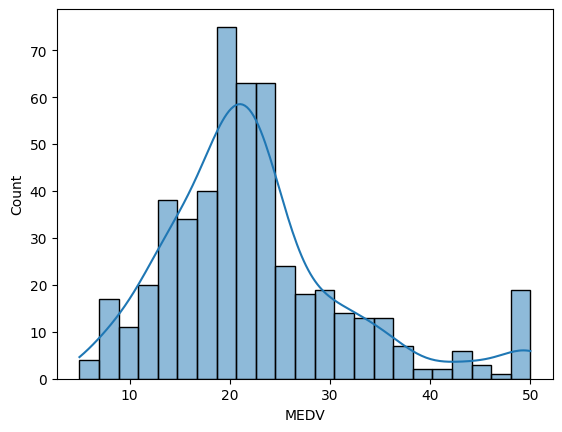

In [6]:
sns.histplot(data=df, x="MEDV", kde=True)
plt.show()

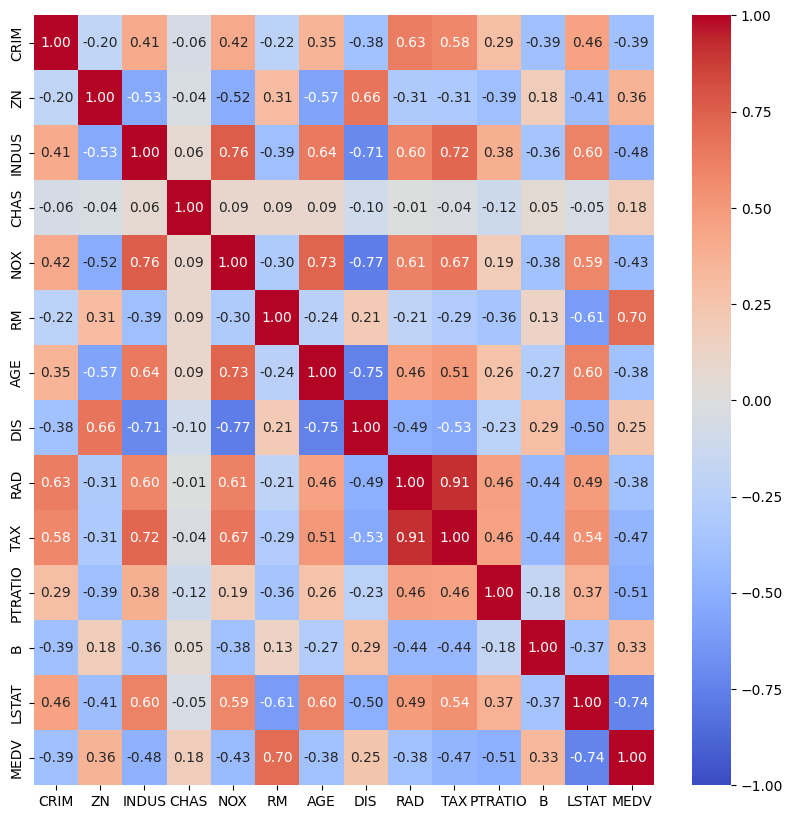

In [7]:
correlations = df.corr()

plt.figure(figsize=(10, 10))
sns.heatmap(correlations, annot=True, fmt=".2f", vmin=-1, vmax=1, cmap="coolwarm")
plt.show()

Take this as an opportunity to explore the data further; look at distributions, relationships, and anything interesting or unusual.

## Getting our Features and Targets

Our target (dependent variable) is the "MEDV" column. So everything else will be our features (independent variables).

In [8]:
X = df.drop(columns=["MEDV"])
y = df[["MEDV"]]

## Splitting into train and test sets

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

## Scaling Numerical Features

`X` (features) and `y` (target) represent completely different things, so they need their own scalers.

In regression, scaling `y` can help the model train more stably. In classification, `y` is a category label (0 or 1), not a number with magnitude, so scaling it makes no sense.

We also keep `y_scaler` as a separate variable so we can call `inverse_transform()` later to convert predictions back to the original unit.

In [10]:
from sklearn.preprocessing import StandardScaler

X_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = X_scaler.fit_transform(X_train)
X_test_scaled = X_scaler.transform(X_test)

y_train_scaled = y_scaler.fit_transform(y_train)

## Training the Model

In [11]:
from sklearn.linear_model import LinearRegression


model = LinearRegression()

model.fit(X_train_scaled, y_train_scaled)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 13)","[[-0.11, 0.07, 0.03,...,-0.22, 0.12,-0.39]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[0.]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,13
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](13,)","[49.35,24.47,22.66,..., 8.51, 8.24, 5.07]"


## Prediction

In [12]:
y_pred = model.predict(X_test_scaled)

When you scale your data, the model learns and predicts in that scaled space. `y_pred` comes out scaled too and is not in the original house price units. We must convert those scaled predictions back to the original scale, so that our results are interpretable.

In [13]:
y_pred = y_scaler.inverse_transform(y_pred)

## Evaluation

In [14]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score

### Mean Squared Error (MSE)

Mean Squared Error represents the average of the squared difference between the original and predicted values in the data set. Squaring serves two purposes: it makes all errors positive, and it penalizes large errors more heavily than small ones. That means a prediction that is way off hurts the score disproportionately more than one that is slightly off. MSE is also sensitive to outliers.

$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

where:
- $y_i$ is the actual value for the an observation.
- $\hat{y_i}$ is the predicted value for an observation.
- $n$ is the number of observations.

The closer MSE is to 0, the better.

In [15]:
mean_squared_error(y_test, y_pred)

24.291119474973502

### Root Mean Squared Error (RMSE)

RMSE is simply the square root of MSE. Because MSE squares the errors, its unit is also squared, thus making it hard to interpret directly. Taking the square root brings the error back to the same unit as the target variable.

$$
\text{RMSE} = \sqrt{ \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 } = \sqrt{\text{MSE}}
$$

In [16]:
root_mean_squared_error(y_test, y_pred)

4.928602182665335

### Mean Absolute Error (MAE)

MAE takes the difference between each actual and predicted value, ignores the sign (absolute value), and averages them. A prediction that is way off is penalized proportionally. This makes MAE more robust to outliers.

$$
\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
$$

In [17]:
mean_absolute_error(y_test, y_pred)

3.1890919658878474

### R-squared (Coefficient of determination)

R-squared (Coefficient of Determination) is a measure of how well a regression model fits the observed data. It quantifies the proportion of the variance in the target variable that is explained by the model.

- R-squared values usually range between **0 and 1**.

- An R-squared of **1** indicates a perfect fit, where the model explains all the variance in the data.

- An R-squared of **0** means the model explains none of the variance. It predicts no better than simply using the mean.

- R-squared can also be **negative** if the model performs worse than a simple horizontal line at the mean (this can happen for very poor models).

$$
R^2 = 1 - \frac{SSE}{SST}
$$

where:
- $\text{SST}$ is the **Total Sum of Squares**, which measures the total variance in the observed data:
  $$
  SST = \sum_{i=1}^{n} (y_i - \bar{y})^2
  $$
- $\text{SSE}$ is the **Sum of Squared Errors** (or Residual Sum of Squares), which measures the variance unexplained by the model:
  $$
  SSE = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
  $$
- $y_i$ is the actual value of an observation.
- $\hat{y}_i$ is the predicted value of an observation.
- $\bar{y}$ is the mean of the actual values.

In [18]:
r2_score(y_test, y_pred)

0.6687594935356322

## Assignment

**Dataset:** https://www.kaggle.com/datasets/camnugent/california-housing-prices

The data pertains to the houses found in a given California district and some summary stats about them based on the 1990 census data. Predict the median house prices with linear regression.